# Read data from AIDev dataset

In [2]:
import pandas as pd

# Read the repos with more than 100 GitHub stars 
# Commit diffs (Additions, deletions, patches) 
original_df_commit_details = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_commit_details.parquet")
original_df_prs = pd.read_parquet("hf://datasets/hao-li/AIDev/pull_request.parquet")
original_df_repos = pd.read_parquet("hf://datasets/hao-li/AIDev/repository.parquet")
original_df_issues = pd.read_parquet("hf://datasets/hao-li/AIDev/issue.parquet")
original_df_related_issues = pd.read_parquet("hf://datasets/hao-li/AIDev/related_issue.parquet")

c:\Users\User\Desktop\Modular-SWE\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_commit_details = original_df_commit_details
df_prs = original_df_prs 
df_repos = original_df_repos
df_issues = original_df_issues 
df_related_issues = original_df_related_issues 

print(df_commit_details.columns)
print(df_prs.columns)
print(df_repos.columns)
print(df_issues.columns)
print(df_related_issues.columns)

Index(['sha', 'pr_id', 'author', 'committer', 'message', 'commit_stats_total',
       'commit_stats_additions', 'commit_stats_deletions', 'filename',
       'status', 'additions', 'deletions', 'changes', 'patch'],
      dtype='str')
Index(['id', 'number', 'title', 'body', 'agent', 'user_id', 'user', 'state',
       'created_at', 'closed_at', 'merged_at', 'repo_id', 'repo_url',
       'html_url'],
      dtype='str')
Index(['id', 'url', 'license', 'full_name', 'language', 'forks', 'stars'], dtype='str')
Index(['id', 'number', 'title', 'body', 'user', 'state', 'created_at',
       'closed_at', 'html_url'],
      dtype='str')
Index(['pr_id', 'issue_id', 'source'], dtype='str')


In [4]:
print(df_repos["language"].value_counts())

language
TypeScript       650
Python           530
Go               242
C#               220
JavaScript       190
                ... 
Nushell            1
PLpgSQL            1
Nextflow           1
JetBrains MPS      1
Jsonnet            1
Name: count, Length: 85, dtype: int64


In [5]:
print(df_prs["agent"].value_counts())

agent
OpenAI_Codex    21799
Copilot          4970
Devin            4827
Cursor           1541
Claude_Code       459
Name: count, dtype: int64


# Filter data 

In [6]:
# Filter out only Python repos 
df_repos = df_repos[df_repos["language"] == "Python"]

# Filter out only closed issues 
df_issues = df_issues[df_issues["state"] == "closed"] 

# Filter out only closed prs 
df_prs = df_prs[df_prs["state"] == "closed"]

## Show the trend of the total number of additions per commit. 
Extract the portion with the greatest number of additions that is likely to associate with a major feature implementation, instead of bug fixes. Extracting the top 10% for now 

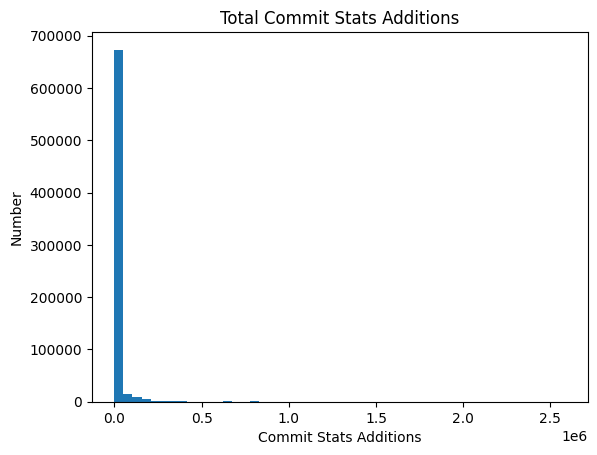

17604.748484035492 769.0
29451.0
86315


In [7]:
import matplotlib.pyplot as plt

data = df_commit_details[["commit_stats_additions"]]

plt.figure()
plt.hist(data, bins=50)
plt.xlabel("Commit Stats Additions")
plt.ylabel("Number")
plt.title("Total Commit Stats Additions")
plt.show()

print(data.mean().values[0], data.median().values[0])
q = data.quantile(0.9).values[0]
print(data.quantile(0.9).values[0])
print(len(df_commit_details["sha"].unique()))

# Joins

In [8]:
# Join the issues to pr tables, 
# by first joining the issues table with the related issues table on issue id
# then joining the pr table on the pr id 
renamed_issues = df_issues[["id", "title", "body", "number"]].rename(columns={"id": "issue_id", "title": "issue_title",
                     "body": "issue_body", "number": "issue_number"})
renamed_prs = df_prs[["id", "number", "title", "body", "agent", "repo_url", "html_url"]].rename(columns={"id": "pr_id", "number": "pr_number", "title": "pr_title", "body": "pr_body"})
issue_to_pr = renamed_issues.merge(df_related_issues[["pr_id", "issue_id"]], on="issue_id").merge(renamed_prs, on="pr_id")

display(issue_to_pr.head())

# Join the issues pr tables to commit details 
# using the pr id 
issue_to_commit_details = issue_to_pr.merge(df_commit_details[["pr_id", "sha", "message", "filename", "status", "additions", "deletions", "changes"]], on="pr_id")

display(issue_to_commit_details.head())
print(issue_to_commit_details.shape)
print(issue_to_commit_details.columns)

,issue_id,issue_title,issue_body,issue_number,pr_id,pr_number,pr_title,pr_body,agent,repo_url,html_url
0,3082498013,Accept api_key in from_provider,**Is your feature request related to a problem...,1542,3240533897,1717,feat(auto_client): add comprehensive api_key p...,## Summary\n\nThis PR adds comprehensive `api_...,Claude_Code,https://api.github.com/repos/567-labs/instructor,https://github.com/567-labs/instructor/pull/1717
1,3082498013,Accept api_key in from_provider,**Is your feature request related to a problem...,1542,3084744894,1553,feat: Add api_key parameter to from_provider f...,# Add api_key parameter to from_provider funct...,Devin,https://api.github.com/repos/567-labs/instructor,https://github.com/567-labs/instructor/pull/1553
2,3082498013,Accept api_key in from_provider,**Is your feature request related to a problem...,1542,3084794264,1554,Fix Python 3.9 compatibility issues in from_pr...,# Fix Python 3.9 compatibility issues in from_...,Devin,https://api.github.com/repos/567-labs/instructor,https://github.com/567-labs/instructor/pull/1554
3,3164229012,Workflows Coming Soon - tools reimagined,### Project Version\n\n5.5.0\n\n### Bug Descri...,94,3164250713,95,🚀 Major Enhancement: Workflow-Based Tool Archi...,# 🚀 Major Enhancement: Workflow-Based Tool Arc...,Claude_Code,https://api.github.com/repos/BeehiveInnovation...,https://github.com/BeehiveInnovations/zen-mcp-...
4,3198054361,[bug]PromptX工具沙箱缓存机制不支持工具集更新,"当工具集需要改进的时候, 会遇到改进后代码和沙箱中的代码不一致的情况.对鲁班自己调试代码造成...",107,3203910456,114,feat: 解决工具沙箱缓存机制问题，增加forceReinstall参数支持,## 🎯 问题背景\n\n解决 Issue #107：PromptX工具沙箱缓存机制不支持工...,Claude_Code,https://api.github.com/repos/Deepractice/PromptX,https://github.com/Deepractice/PromptX/pull/114


,issue_id,issue_title,issue_body,issue_number,pr_id,pr_number,pr_title,pr_body,agent,repo_url,html_url,sha,message,filename,status,additions,deletions,changes
0,3082498013,Accept api_key in from_provider,**Is your feature request related to a problem...,1542,3240533897,1717,feat(auto_client): add comprehensive api_key p...,## Summary\n\nThis PR adds comprehensive `api_...,Claude_Code,https://api.github.com/repos/567-labs/instructor,https://github.com/567-labs/instructor/pull/1717,f5dd5e737963ec0f6df35ae8d2fc337aeb0b99fa,feat(auto_client): add comprehensive api_key p...,instructor/auto_client.py,modified,60.0,22.0,82.0
1,3082498013,Accept api_key in from_provider,**Is your feature request related to a problem...,1542,3240533897,1717,feat(auto_client): add comprehensive api_key p...,## Summary\n\nThis PR adds comprehensive `api_...,Claude_Code,https://api.github.com/repos/567-labs/instructor,https://github.com/567-labs/instructor/pull/1717,0e5e9da476f9dac42341238be15461aadac1d460,test(auto_client): add comprehensive tests for...,instructor/auto_client.py,modified,2.0,1.0,3.0
2,3082498013,Accept api_key in from_provider,**Is your feature request related to a problem...,1542,3240533897,1717,feat(auto_client): add comprehensive api_key p...,## Summary\n\nThis PR adds comprehensive `api_...,Claude_Code,https://api.github.com/repos/567-labs/instructor,https://github.com/567-labs/instructor/pull/1717,0e5e9da476f9dac42341238be15461aadac1d460,test(auto_client): add comprehensive tests for...,tests/test_auto_client.py,modified,133.0,0.0,133.0
3,3082498013,Accept api_key in from_provider,**Is your feature request related to a problem...,1542,3240533897,1717,feat(auto_client): add comprehensive api_key p...,## Summary\n\nThis PR adds comprehensive `api_...,Claude_Code,https://api.github.com/repos/567-labs/instructor,https://github.com/567-labs/instructor/pull/1717,64b26da4ae1acd6be60c8957d7d18262eed2534d,docs: add api_key parameter examples to README...,README.md,modified,5.0,0.0,5.0
4,3082498013,Accept api_key in from_provider,**Is your feature request related to a problem...,1542,3240533897,1717,feat(auto_client): add comprehensive api_key p...,## Summary\n\nThis PR adds comprehensive `api_...,Claude_Code,https://api.github.com/repos/567-labs/instructor,https://github.com/567-labs/instructor/pull/1717,64b26da4ae1acd6be60c8957d7d18262eed2534d,docs: add api_key parameter examples to README...,docs/index.md,modified,5.0,0.0,5.0


(119612, 18)
Index(['issue_id', 'issue_title', 'issue_body', 'issue_number', 'pr_id',
       'pr_number', 'pr_title', 'pr_body', 'agent', 'repo_url', 'html_url',
       'sha', 'message', 'filename', 'status', 'additions', 'deletions',
       'changes'],
      dtype='str')


## Extract commits with the top k% commit stats additions
High additions indicate the issue is likely a feature implementation and not a simple bug fix. 

In [9]:
# Sum the issues to commit details per number of additions per PR 
issue_to_commit_details_sum_additions = issue_to_commit_details.groupby("pr_id")["additions"].sum() 

# Find the pr_ids corresponding to the top 5% of additions 
threshold = issue_to_commit_details_sum_additions.quantile(0.95) 
significant_pr_ids = issue_to_commit_details_sum_additions[issue_to_commit_details_sum_additions > threshold].index 
issue_to_commit_details_filtered = issue_to_commit_details[issue_to_commit_details["pr_id"].isin(significant_pr_ids)]

display(issue_to_commit_details_filtered)
print(len(issue_to_commit_details_filtered["pr_id"].unique()))

,issue_id,issue_title,issue_body,issue_number,pr_id,pr_number,pr_title,pr_body,agent,repo_url,html_url,sha,message,filename,status,additions,deletions,changes
12,3164229012,Workflows Coming Soon - tools reimagined,### Project Version\n\n5.5.0\n\n### Bug Descri...,94,3164250713,95,🚀 Major Enhancement: Workflow-Based Tool Archi...,# 🚀 Major Enhancement: Workflow-Based Tool Arc...,Claude_Code,https://api.github.com/repos/BeehiveInnovation...,https://github.com/BeehiveInnovations/zen-mcp-...,316db13a3a3bf01572e588e17bfc8dd4780c8a35,WIP: new workflow architecture,debug_certain_confidence.py,added,74.0,0.0,74.0
13,3164229012,Workflows Coming Soon - tools reimagined,### Project Version\n\n5.5.0\n\n### Bug Descri...,94,3164250713,95,🚀 Major Enhancement: Workflow-Based Tool Archi...,# 🚀 Major Enhancement: Workflow-Based Tool Arc...,Claude_Code,https://api.github.com/repos/BeehiveInnovation...,https://github.com/BeehiveInnovations/zen-mcp-...,316db13a3a3bf01572e588e17bfc8dd4780c8a35,WIP: new workflow architecture,server.py,modified,7.0,0.0,7.0
14,3164229012,Workflows Coming Soon - tools reimagined,### Project Version\n\n5.5.0\n\n### Bug Descri...,94,3164250713,95,🚀 Major Enhancement: Workflow-Based Tool Archi...,# 🚀 Major Enhancement: Workflow-Based Tool Arc...,Claude_Code,https://api.github.com/repos/BeehiveInnovation...,https://github.com/BeehiveInnovations/zen-mcp-...,316db13a3a3bf01572e588e17bfc8dd4780c8a35,WIP: new workflow architecture,simulator_tests/__init__.py,modified,3.0,0.0,3.0
15,3164229012,Workflows Coming Soon - tools reimagined,### Project Version\n\n5.5.0\n\n### Bug Descri...,94,3164250713,95,🚀 Major Enhancement: Workflow-Based Tool Archi...,# 🚀 Major Enhancement: Workflow-Based Tool Arc...,Claude_Code,https://api.github.com/repos/BeehiveInnovation...,https://github.com/BeehiveInnovations/zen-mcp-...,316db13a3a3bf01572e588e17bfc8dd4780c8a35,WIP: new workflow architecture,simulator_tests/conversation_base_test.py,modified,3.0,2.0,5.0
16,3164229012,Workflows Coming Soon - tools reimagined,### Project Version\n\n5.5.0\n\n### Bug Descri...,94,3164250713,95,🚀 Major Enhancement: Workflow-Based Tool Archi...,# 🚀 Major Enhancement: Workflow-Based Tool Arc...,Claude_Code,https://api.github.com/repos/BeehiveInnovation...,https://github.com/BeehiveInnovations/zen-mcp-...,316db13a3a3bf01572e588e17bfc8dd4780c8a35,WIP: new workflow architecture,simulator_tests/test_debugworkflow_validation.py,added,552.0,0.0,552.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116038,3105387986,Cloudflare Secrets Store,We need to add support for Cloudflare Secrets ...,244,3105417177,250,feat: implement Cloudflare Secrets Store resource,# Implement Cloudflare Secrets Store Resource\...,Devin,https://api.github.com/repos/sam-goodwin/alchemy,https://github.com/sam-goodwin/alchemy/pull/250,1dfbbacf373f127213295c0ae908917a9059e582,Merge branch 'main' into devin/1748693060-gith...,alchemy-web/public/og-images/docs-providers-aw...,added,0.0,0.0,0.0
116039,3105387986,Cloudflare Secrets Store,We need to add support for Cloudflare Secrets ...,244,3105417177,250,feat: implement Cloudflare Secrets Store resource,# Implement Cloudflare Secrets Store Resource\...,Devin,https://api.github.com/repos/sam-goodwin/alchemy,https://github.com/sam-goodwin/alchemy/pull/250,1dfbbacf373f127213295c0ae908917a9059e582,Merge branch 'main' into devin/1748693060-gith...,alchemy-web/public/og-images/docs-providers-aw...,added,0.0,0.0,0.0
116040,3105387986,Cloudflare Secrets Store,We need to add support for Cloudflare Secrets ...,244,3105417177,250,feat: implement Cloudflare Secrets Store resource,# Implement Cloudflare Secrets Store Resource\...,Devin,https://api.github.com/repos/sam-goodwin/alchemy,https://github.com/sam-goodwin/alchemy/pull/250,1dfbbacf373f127213295c0ae908917a9059e582,Merge branch 'main' into devin/1748693060-gith...,alchemy-web/public/og-images/docs-providers-aw...,added,0.0,0.0,0.0
116041,3105387986,Cloudflare Secrets Store,We need 

163


## Git clone the repo before and after each pull request

In [10]:
# Extract unique pr ids 
unique_pr_ids = issue_to_commit_details_filtered["pr_id"].unique()

# Currently, extract the first pr id that exists, and extract the first row per commit list
first_row = issue_to_commit_details_filtered[issue_to_commit_details_filtered["pr_id"] == unique_pr_ids[0]].iloc[0]
display(first_row)


issue_id                                               3164229012
issue_title              Workflows Coming Soon - tools reimagined
issue_body      ### Project Version\n\n5.5.0\n\n### Bug Descri...
issue_number                                                   94
pr_id                                                  3164250713
pr_number                                                      95
pr_title        🚀 Major Enhancement: Workflow-Based Tool Archi...
pr_body         # 🚀 Major Enhancement: Workflow-Based Tool Arc...
agent                                                 Claude_Code
repo_url        https://api.github.com/repos/BeehiveInnovation...
html_url        https://github.com/BeehiveInnovations/zen-mcp-...
sha                      316db13a3a3bf01572e588e17bfc8dd4780c8a35
message                            WIP: new workflow architecture
filename                              debug_certain_confidence.py
status                                                      added
additions 

In [11]:
from dotenv import load_dotenv
import os

load_dotenv()

USERNAME = os.environ["GITHUB_USERNAME"]
TOKEN = os.environ["GITHUB_TOKEN"]

In [13]:
# Given a row in the issue_to_commit_details, clone its before and after version to the folder 
# Will not clone or modify any files if it already exists. 
# /pr_id/before and /pr_id/after
import os 
import subprocess
import requests 
def clone_repo(row): 
    # Append the pr number to the repo url 
    # https://docs.github.com/en/rest/pulls/pulls?apiVersion=2026-03-10
    fetchUrl = f"{row["repo_url"]}/pulls/{row["pr_number"]}"
    pr_id = row["pr_id"]
    
    # GET request to the GitHub API 
    headers = {"Authorization": f"Bearer {TOKEN}",}
    response = requests.get(fetchUrl, headers=headers)
    if response.status_code != 200: 
        raise Exception(f"{response.status_code} Fail to fetch url {fetchUrl}")

    # Extract the base SHA (before) and merge commit SHA (after) 
    resjson = response.json()
    base_SHA = resjson["base"]["sha"]
    merge_commit_SHA = resjson["merge_commit_sha"]

    # Obtain the base clone url and name
    # Base branch is the branch where changes are pulled into 
    base_clone_url = resjson["base"]["repo"]["clone_url"]
    base_repo_name = resjson["base"]["repo"]["name"]

    # Create a before and after folder for each pr id 
    before_dir = f"snapshots/{pr_id}/before"
    after_dir = f"snapshots/{pr_id}/after"
    os.makedirs(before_dir, exist_ok=True)
    os.makedirs(after_dir, exist_ok=True)

    # clone the before and after version of the repo, checking out to the base and commit SHA
    # Only perform this when the folders are empty 
    wd = os.getcwd()  # for changing back to the current working dir later 
    if len(os.listdir(before_dir)) == 0:  
        os.chdir(before_dir)
        subprocess.run(["git", "clone", base_clone_url])
        os.chdir(base_repo_name)
        subprocess.run(["git", "checkout", base_SHA])  # SHA before merge 
        os.chdir(wd)  

    if len(os.listdir(after_dir)) == 0:  
        os.chdir(after_dir)
        subprocess.run(["git", "clone", base_clone_url])
        os.chdir(base_repo_name)
        subprocess.run(["git", "checkout", merge_commit_SHA])  # SHA after merge 
        os.chdir(wd)  


In [14]:
clone_repo(first_row)